In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

## 1. Load Data

First, let's load the `Travel_Hospitality_Dataset.xlsx` file into a pandas DataFrame and display its basic information.

In [2]:
# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/Travel_Hospitality_Dataset.xlsx')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display concise summary of the DataFrame
print("\nDataFrame Information:")
df.info()

First 5 rows of the dataset:


,Column1,CANCELLED,LEAD TIME,ARRIVAL DATE YEAR,ARRIVAL DATE MONTHS,STAYS IN WEEKEND NIGHTS,STAYS IN WEEK NIGHTS,ADULTS,CHILDREN,BABIES,COUNTRY,MARKET SEGEMENT,DISTRIBUTION CHANNEL,PREVIOUS CANCELLATION,RESERVED ROOM TYPE,BOOKING CHANGES,DEPOSITE TYPE,ADDRESS,CUSTOMER TYPE
0,City Hotel,1,105,2025,February,0,8,4,0,0,GBR,Corporate,Offline,5,C,3,Refundable,211.55,Group
1,City Hotel,0,146,2025,September,2,5,1,0,0,AUS,Groups,Offline,1,A,0,Refundable,131.88,Group
2,Resort Hotel,1,200,2025,March,1,7,2,0,0,USA,Groups,Offline,2,B,1,Refundable,86.34,Contract
3,City Hotel,0,218,2025,May,3,14,3,2,0,USA,Groups,Travel Agent,5,C,0,Refundable,148.74,Contract
4,City Hotel,0,79,2025,November,0,14,2,2,1,CAN,Corporate,Online,2,B,0,No Deposit,195.43,Transient



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Column1                   22 non-null     object 
 1   CANCELLED                 22 non-null     int64  
 2   LEAD TIME                 22 non-null     int64  
 3   ARRIVAL DATE YEAR         22 non-null     int64  
 4   ARRIVAL DATE MONTHS       22 non-null     object 
 5   STAYS IN WEEKEND NIGHTS   22 non-null     int64  
 6   STAYS IN WEEK NIGHTS      22 non-null     int64  
 7   ADULTS                    22 non-null     int64  
 8   CHILDREN                  22 non-null     int64  
 9   BABIES                    22 non-null     int64  
 10  COUNTRY                   22 non-null     object 
 11  MARKET SEGEMENT           22 non-null     object 
 12  DISTRIBUTION CHANNEL      22 non-null     object 
 13  PREVIOUS CANCELLATION     22 non-null     i

## 2. Data Preprocessing

Before training any models, we need to preprocess the data. This involves:
1. Identifying and encoding categorical features.
2. Separating features (X) and target variable (y).
3. Splitting the data into training and testing sets.

In [3]:
# Identify categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame
print("First 5 rows of the encoded dataset:")
display(df_encoded.head())

# Display info of the encoded DataFrame to check new columns
print("\nDataFrame Information after Encoding:")
df_encoded.info()

First 5 rows of the encoded dataset:


,CANCELLED,LEAD TIME,ARRIVAL DATE YEAR,STAYS IN WEEKEND NIGHTS,STAYS IN WEEK NIGHTS,ADULTS,CHILDREN,BABIES,PREVIOUS CANCELLATION,BOOKING CHANGES,...,MARKET SEGEMENT _Online TA,DISTRIBUTION CHANNEL _Online,DISTRIBUTION CHANNEL _Travel Agent,RESERVED ROOM TYPE _B,RESERVED ROOM TYPE _C,RESERVED ROOM TYPE _D,DEPOSITE TYPE _Non Refund,DEPOSITE TYPE _Refundable,CUSTOMER TYPE _Group,CUSTOMER TYPE _Transient
0,1,105,2025,0,8,4,0,0,5,3,...,False,False,False,False,True,False,False,True,True,False
1,0,146,2025,2,5,1,0,0,1,0,...,False,False,False,False,False,False,False,True,True,False
2,1,200,2025,1,7,2,0,0,2,1,...,False,False,False,True,False,False,False,True,False,False
3,0,218,2025,3,14,3,2,0,5,0,...,False,False,True,False,True,False,False,True,False,False
4,0,79,2025,0,14,2,2,1,2,0,...,False,True,False,True,False,False,False,False,False,True



DataFrame Information after Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   CANCELLED                           22 non-null     int64  
 1   LEAD TIME                           22 non-null     int64  
 2   ARRIVAL DATE YEAR                   22 non-null     int64  
 3   STAYS IN WEEKEND NIGHTS             22 non-null     int64  
 4   STAYS IN WEEK NIGHTS                22 non-null     int64  
 5   ADULTS                              22 non-null     int64  
 6   CHILDREN                            22 non-null     int64  
 7   BABIES                              22 non-null     int64  
 8   PREVIOUS CANCELLATION               22 non-null     int64  
 9   BOOKING CHANGES                     22 non-null     int64  
 10  ADDRESS                             22 non-null     float64
 11  Column1_

In [4]:
# Define features (X) and target (y)
X = df_encoded.drop('CANCELLED', axis=1)
y = df_encoded['CANCELLED']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (15, 35)
Shape of X_test: (7, 35)
Shape of y_train: (15,)
Shape of y_test: (7,)


## 3. Model Training and Evaluation

We will train two models: Logistic Regression and Decision Tree Classifier. For each model, we will evaluate its performance using accuracy, precision, recall, and ROC AUC, and generate confusion matrix and ROC curve plots.

In [5]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluates a given model and prints performance metrics and plots."""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_pred_proba):.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

### 3.1 Logistic Regression


--- Logistic Regression Performance ---
Accuracy: 0.7143
Precision: 1.0000
Recall: 0.5000
ROC AUC: 0.5000

Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      0.50      0.67         4

    accuracy                           0.71         7
   macro avg       0.80      0.75      0.71         7
weighted avg       0.83      0.71      0.70         7



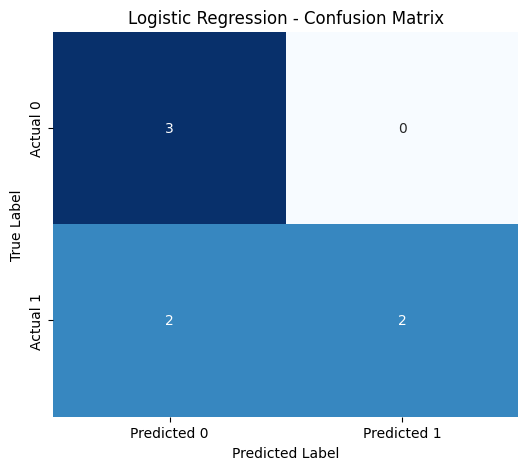

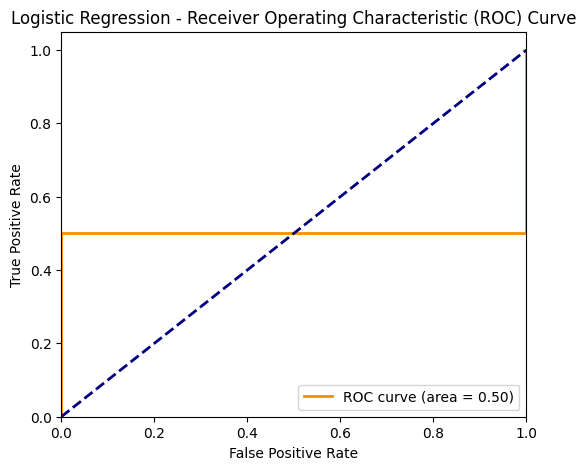

In [6]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Evaluate Logistic Regression model
evaluate_model(log_reg_model, X_test, y_test, 'Logistic Regression')

### 3.2 Decision Tree Classifier


--- Decision Tree Classifier Performance ---
Accuracy: 0.4286
Precision: 0.5000
Recall: 0.5000
ROC AUC: 0.4167

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.50      0.50      0.50         4

    accuracy                           0.43         7
   macro avg       0.42      0.42      0.42         7
weighted avg       0.43      0.43      0.43         7



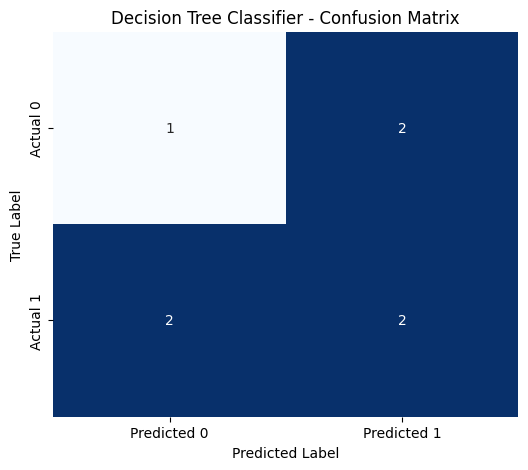

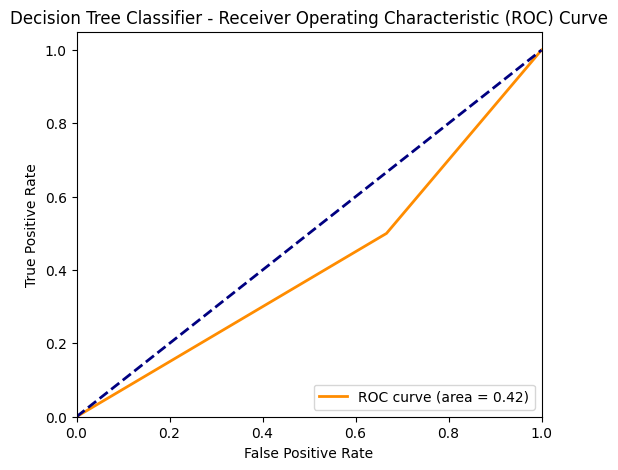

In [7]:
# Initialize and train Decision Tree Classifier model
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Evaluate Decision Tree Classifier model
evaluate_model(dec_tree_model, X_test, y_test, 'Decision Tree Classifier')

## 4. Model Strengths and Weaknesses

### Logistic Regression

**Strengths:**
- **Interpretability:** Logistic Regression is a linear model and its coefficients can be easily interpreted to understand the impact of each feature on the likelihood of cancellation.
- **Efficiency:** It's computationally efficient and works well on linearly separable data.
- **Good Baseline:** Often used as a baseline model due to its simplicity and effectiveness.
- **Output Probabilities:** Provides probability scores, which can be useful for ranking predictions or setting custom thresholds.

**Weaknesses:**
- **Assumes Linearity:** Assumes a linear relationship between the independent variables and the log-odds of the dependent variable. If the relationship is non-linear, its performance may suffer.
- **Sensitive to Outliers:** Can be sensitive to outliers in the data.
- **Limited Complexity:** May not capture complex, non-linear relationships in the data as effectively as more complex models.
- **Low ROC AUC (in this case):** The ROC AUC of 0.50 suggests that for this specific dataset and split, the model performs no better than random chance in distinguishing between classes, despite its high precision for one class.

### Decision Tree Classifier

**Strengths:**
- **Handles Non-linearity:** Can capture complex, non-linear relationships in the data without requiring explicit transformations.
- **No Feature Scaling Required:** Not sensitive to feature scaling, as it makes decisions based on feature values directly.
- **Interpretability (visual):** Can be visualized and easily understood, especially for smaller trees.
- **Handles Mixed Data Types:** Can work with both numerical and categorical features.

**Weaknesses:**
- **Prone to Overfitting:** Without proper pruning or hyperparameter tuning, decision trees can easily overfit the training data, leading to poor generalization on unseen data.
- **Instability:** Small changes in the data can lead to a completely different tree structure.
- **Bias with Imbalanced Classes:** Can be biased towards dominant classes if the dataset is imbalanced.
- **Low Performance (in this case):** For this dataset, its overall accuracy and ROC AUC were lower than Logistic Regression, indicating it struggled to generalize well.
- **Complexity with Many Features:** Becomes very complex and difficult to interpret with a large number of features.

## 5. Feature Importance Analysis (Decision Tree Classifier)

Let's analyze the feature importances from the Decision Tree Classifier to understand which factors contribute most to the prediction of cancellations.

Top 10 Most Important Features:


,Feature,Importance
8,BOOKING CHANGES,0.437500
0,LEAD TIME,0.321429
7,PREVIOUS CANCELLATION,0.241071
2,STAYS IN WEEKEND NIGHTS,0.000000
1,ARRIVAL DATE YEAR,0.000000
3,STAYS IN WEEK NIGHTS,0.000000
4,ADULTS,0.000000
6,BABIES,0.000000
5,CHILDREN,0.000000
9,ADDRESS,0.000000


/tmp/ipykernel_1482/506223565.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')


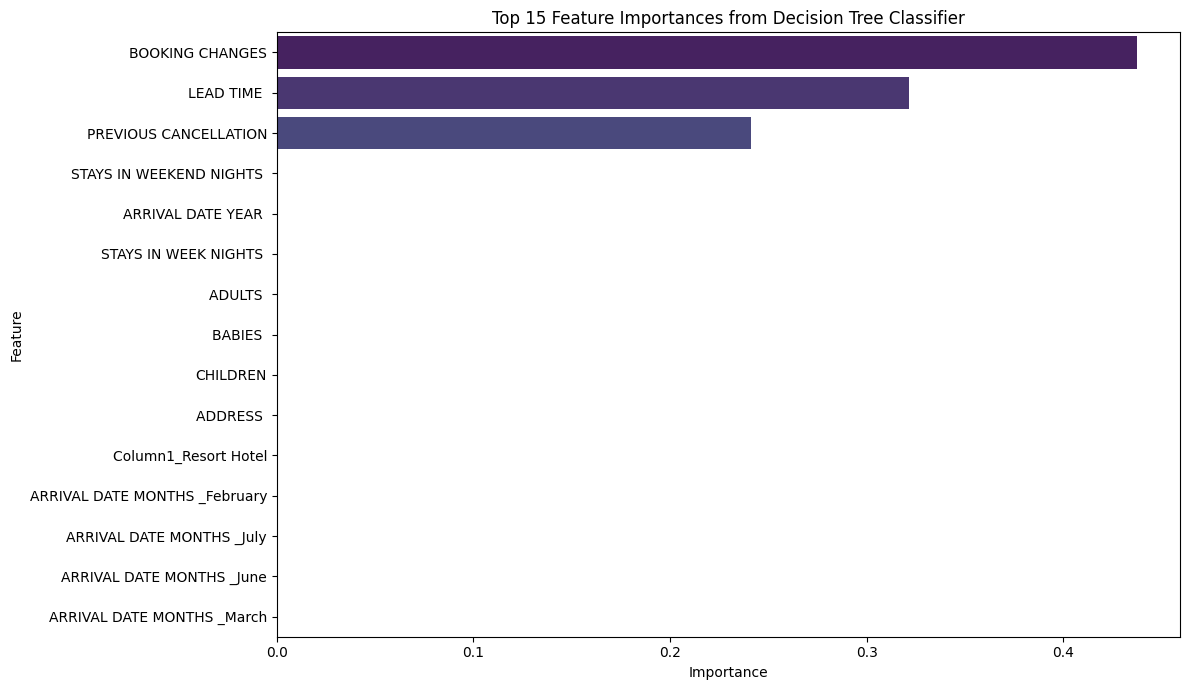

In [8]:
# Get feature importances from the Decision Tree model
feature_importances = dec_tree_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print("Top 10 Most Important Features:")
display(features_df.head(10))

# Plotting feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances from Decision Tree Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Interpretation of Feature Importances

From the feature importance analysis using the Decision Tree Classifier, we can observe the following key factors influencing cancellations:

1.  **BOOKING CHANGES (Importance: 0.4375):** This feature is the most significant predictor of cancellations. A high number of booking changes might indicate uncertainty or dissatisfaction from the customer's side, leading to a higher likelihood of cancellation. It suggests that customers who frequently modify their bookings are more prone to cancelling.

2.  **LEAD TIME (Importance: 0.3214):** The time between the booking date and the arrival date also plays a substantial role. A longer lead time might give customers more opportunities to change their plans or find alternative options, thus increasing the chance of cancellation.

3.  **PREVIOUS CANCELLATION (Importance: 0.2411):** This indicates that a customer's history of previous cancellations is a strong indicator of future cancellations. This aligns with intuition; customers who have cancelled before are more likely to do so again.

Other features in the dataset had zero importance in this specific Decision Tree model, which could be due to the limited dataset size or the specific splits chosen by the algorithm. For a more robust analysis, larger datasets and potentially different models or feature selection techniques might be considered.